<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml18_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN(Convolutional Neural Network, 합성곱 신경망)

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import convolve, convolve2d, correlate, correlate2d
from sklearn.datasets import load_sample_image, load_sample_images
from sklearn.metrics import confusion_matrix

import keras
import tensorflow as tf

# 합성곱 연산

같은 인덱스의 원소들끼리는 곱하고, 곱한 값들을 모두 더함.

## 1차원 배열 합성곱 연산(1D Convolution)

In [2]:
x = np.arange(1, 5)
print(x)

[1 2 3 4]


In [3]:
y = np.array([1, 2])
print(y)

[1 2]


In [4]:
y_flip = np.flip(y)
print(y_flip)

[2 1]


### `convolve()` 함수

scipy 패키지의 convolve 함수는 배열 y를 반전(flip)시키고 합성곱 연산을 수행.

In [5]:
# 'valid' 모드: 결과가 배열 x보다 크기가 줄어듦.
result = convolve(x, y, mode='valid')
print(result)

[ 4  7 10]


In [6]:
# 'same' 모드: 결과가 배열 x의 크기와 같음.
result = convolve(x, y, mode='same')
print(result)

[ 1  4  7 10]


In [7]:
# 'full' 모드: 배열 x의 모든 원소들이 합성곱 연산에서 같은 비율(횟수)로 참여하도록 패딩을 넣고 연산을 수행.
result = convolve(x, y, mode='full')
print(result)

[ 1  4  7 10  8]


### `correlate()` 함수

교차상관(cross-corrleate): 배열 y를 반전시키지 않고 합성곱 연산을 수행.

In [8]:
result = correlate(x, y, mode='valid')
print(result)

[ 5  8 11]


In [9]:
result = correlate(x, y, mode='same')
print(result)

[ 2  5  8 11]


In [10]:
result = correlate(x, y, mode='full')
print(result)

[ 2  5  8 11  4]


## 2차원 배열 합성곱(2D Convolution)

In [11]:
x = np.arange(1, 17).reshape((4, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [12]:
y = np.array([[0, 1],
              [2, 0]])
print(y)

[[0 1]
 [2 0]]


In [13]:
y_flip = np.flip(y)
print(y_flip)

[[0 2]
 [1 0]]


### `convolve2d()` 함수

In [14]:
result = convolve2d(x, y, mode='valid')
print(result)

[[ 9 12 15]
 [21 24 27]
 [33 36 39]]


In [15]:
result = convolve2d(x, y, mode='same')
print(result)

[[ 0  1  2  3]
 [ 2  9 12 15]
 [10 21 24 27]
 [18 33 36 39]]


In [16]:
result = convolve2d(x, y, mode='full')
print(result)

[[ 0  1  2  3  4]
 [ 2  9 12 15  8]
 [10 21 24 27 12]
 [18 33 36 39 16]
 [26 28 30 32  0]]


### `correlate2d()` 함수

In [17]:
result = correlate2d(x, y, mode='valid')
print(result)

[[12 15 18]
 [24 27 30]
 [36 39 42]]


In [18]:
result = correlate2d(x, y, mode='same')
print(result)

[[12 15 18 16]
 [24 27 30 24]
 [36 39 42 32]
 [14 15 16  0]]


In [19]:
result = correlate2d(x, y, mode='full')
print(result)

[[ 0  2  4  6  8]
 [ 1 12 15 18 16]
 [ 5 24 27 30 24]
 [ 9 36 39 42 32]
 [13 14 15 16  0]]


## 이미지 배열과 합성곱 연산

Python에서 이미지 파일을 다루는 방식

*   숫자들의 배열
    *   숫자들의 스케일
        *   0 ~ 255 정수 스케일
        *   0.0 ~ 1.0 실수 스케일
    *   배열의 모양
        *   흑백 이미지: (height, width) 모양의 2차원 배열
        *   컬러 이미지: (height, width, channel) 모양의 3차원 배열
            *   투명도가 없는 이미지: (height, width, 3). channel = red, green, blue
            *   투명도가 있는 이미지: (heigth, width, 4). channel = reg, green, blue, alpha
*   Keras 패키지에서는 합성곱 층에서 흑백 이미지를 사용할 때 컬러 이미지처럼 3차원 배열로 사용해야 함.
    *   Keras 패키지는 흑백 이미지를 (height, width, 1) 모양의 3차원 배열로 취급.


In [20]:
china = load_sample_image('china.jpg')
china.shape  #> jpg 파일을 읽어서 numpy 배열로 리턴

(427, 640, 3)

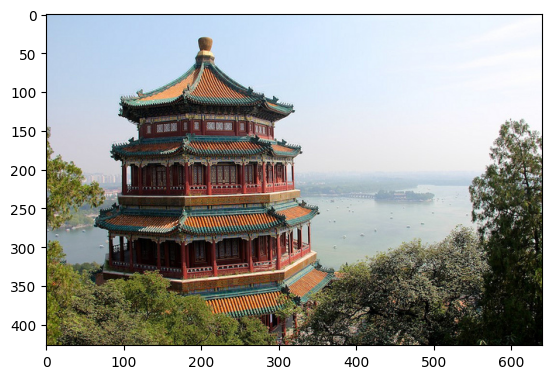

In [21]:
plt.imshow(china)
plt.show()

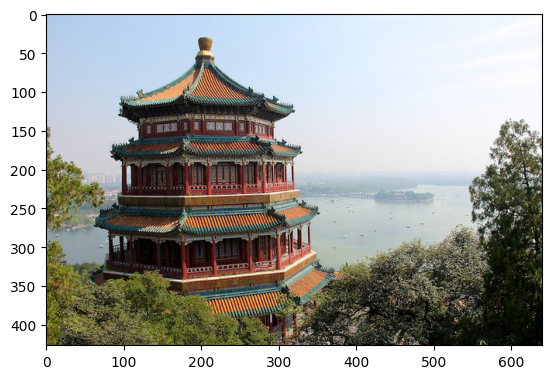

In [22]:
china_scaled = china / 255.0  # 0 ~ 255 정수 스케일을 0.0 ~ 1.0 실수 스케일로 변환
plt.imshow(china_scaled)
plt.show()

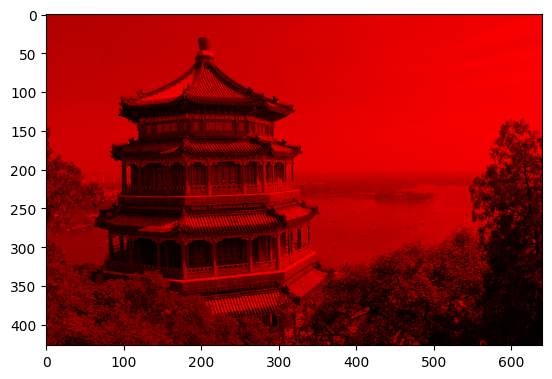

In [23]:
copy = china_scaled.copy()
copy[:, :, [1, 2]] = 0.0  # green, blue 색상을 모두 0으로. red 색상만 남김.
plt.imshow(copy)
plt.show()

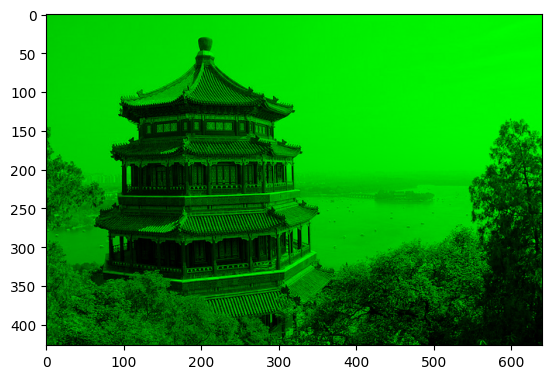

In [24]:
copy = china_scaled.copy()
copy[:, :, [0, 2]] = 0.0  # red, blue 색상을 모두 0으로. green 색상만 남김.
plt.imshow(copy)
plt.show()

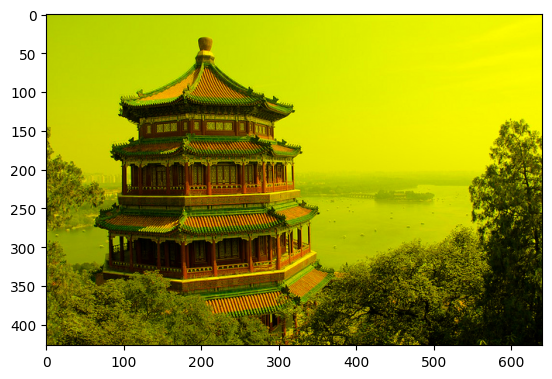

In [25]:
copy = china_scaled.copy()
copy[:, :, 2] = 0.0  # blue 색상만 제거.
plt.imshow(copy)
plt.show()

In [26]:
filter = np.zeros(shape=(3, 3, 3))
filter[:, :, 0] = 1
result = convolve(china, filter, mode='same')
result = result.astype(np.uint8)  # uint8: 8 bits unsigned integer(8bits=1byte 부호 없는 정수)
print(result.shape)

(427, 640, 3)


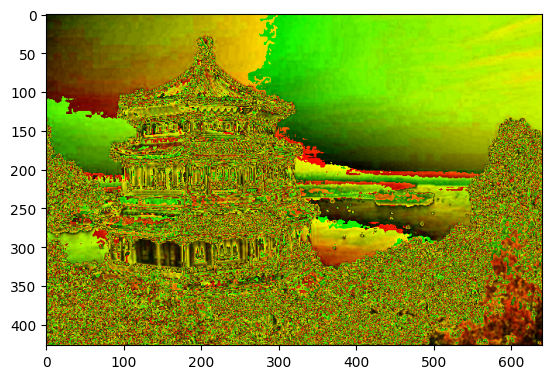

In [27]:
plt.imshow(result)
plt.show()

# Pooling

In [28]:
x = np.arange(1, 21).reshape((5, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]


In [29]:
(3+4+7+8)/4

5.5

In [30]:
# Keras의 Pooling 연산 클래스는 입력값으로 (n_samples, height, width, channel) 형식의 4차원 배열을 사용.
x_4d = x.reshape((1, 5, 4, 1))
print(x_4d)

[[[[ 1]
   [ 2]
   [ 3]
   [ 4]]

  [[ 5]
   [ 6]
   [ 7]
   [ 8]]

  [[ 9]
   [10]
   [11]
   [12]]

  [[13]
   [14]
   [15]
   [16]]

  [[17]
   [18]
   [19]
   [20]]]]


## Max Pooling(최대 풀링)

필터링된 값들 중에서 최댓값을 선택하는 풀링 방식

In [31]:
max_pooling = keras.layers.MaxPool2D()  # 2D max pooling 연산을 수행하는 객체
result = max_pooling(x_4d)  # max pooling 연산 수행
print(type(result))  #> type: Tensor(다차원 배열)
print(result.shape)  #> (1, 2, 2, 1) = (n_samples, height, width, channel)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [32]:
result.numpy().reshape((2, 2))  # Tensor --> numpy 배열 --> 2차원 모양으로 변환

array([[ 6,  8],
       [14, 16]])

## Average Pooling(평균 풀링)

필터링된 값들의 평균값을 선택하는 풀링 방식.

In [33]:
# TensorFlow는 암무적인 타입 변환을 수행하지 않음.(정수는 정수끼리만, 실수는 실수끼리만 연산)
x = x.astype(np.float32)  # 숫자 타입을 32bits(= 4bytes) 실수 타입으로 변환.
x_4d = x.reshape((1, 5, 4, 1))
avg_pooling = keras.layers.AveragePooling2D(pool_size=(2, 2))  # 2D 평균 풀링을 수행하는 객체
result = avg_pooling(x_4d)  # average pooling 연산 수행
print(type(result))  #> 결과는 Tensor
print(result.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [34]:
result.numpy().reshape((2, 2))  # Tensor --> numpy ndarray로 변환 --> (2, 2) 모양의 2차원 배열로 변환

array([[ 3.5,  5.5],
       [11.5, 13.5]], dtype=float32)

## 이미지 배열에서 Pooling

In [35]:
flower = load_sample_image('flower.jpg')
flower.shape

(427, 640, 3)

In [36]:
flower = flower / 255.0  # 각 픽셀의 값들을 0.0 ~ 1.0 스케일로 변환

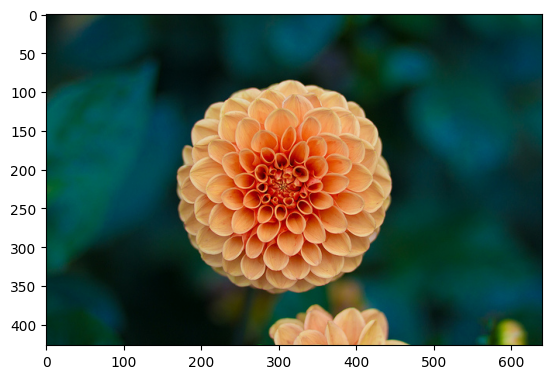

In [37]:
plt.imshow(flower)
plt.show()

In [38]:
x = flower.reshape((1, 427, 640, 3))  # (n_samples, height, width, channel)

In [39]:
max_pooling = keras.layers.MaxPool2D()  # pool_size=(2, 2) 기본값
result = max_pooling(x)
print(result.shape)

(1, 213, 320, 3)


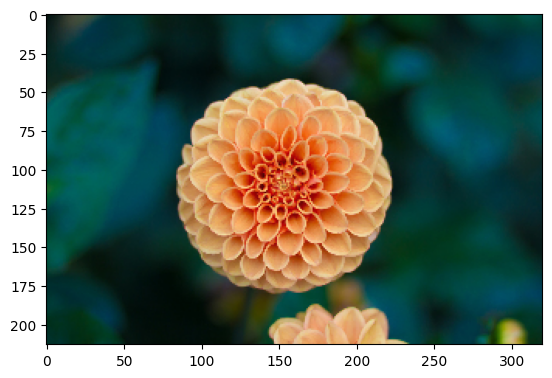

In [40]:
img = result.numpy().reshape((213, 320, 3))
plt.imshow(img)
plt.show()
#> 이미지에서 pooling의 효과는 이미지 크기 축소.

In [41]:
avg_pooling = keras.layers.AveragePooling2D(pool_size=(2, 2))
result = avg_pooling(x)
result.shape

TensorShape([1, 213, 320, 3])

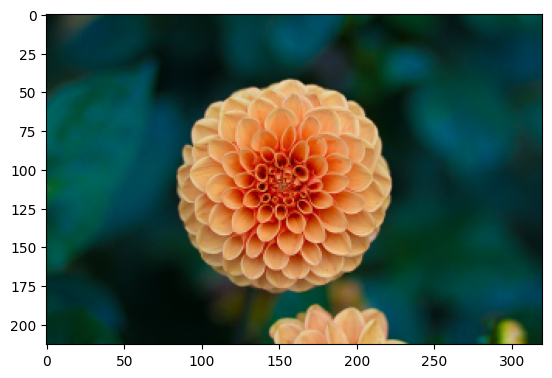

In [42]:
img = result.numpy().reshape((213, 320, 3))
plt.imshow(img)
plt.show()

# Fashion MNIST 데이터셋

In [43]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
print(x_train.shape)  #> (n_samples, height, width)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


*   신경망 훈련을 빠르게 하기 위해서 0 ~ 255 스케일을 0.0 ~ 1.0 스케일로 변환
*   합성곱/풀링 연산을 수행할 수 있도록 하기 위해서, 훈련셋과 테스트셋의 모양을 (n_samples, height, width, channel) 모양의 4차원으로 변환(channel=1).

In [45]:
# 실수(0 ~ 1) 스케일로 변환
x_train_sc = x_train / 255.0
x_test_sc = x_test / 255.0

In [46]:
# 4차원 모양으로 변환
x_train_sc = x_train_sc.reshape((60_000, 28, 28, 1))
x_test_sc = x_test_sc.reshape((10_000, 28, 28, 1))

# 합성곱 신경망(CNN, Convolutional Neural Network)

Input --> Conv2D --> MaxPool2D --> Conv2D --> MaxPool2D --> Flatten --> Dense --> Dropout --> Output

*   Convolution layer(합성곱 층)
    *   filter(필터): 합성곱 층에서의 유닛(unit)
    *   kernel(커널): 필터의 값들. 합성곱 연산에서 입력값에 곱해주는 가중치들(weights). 모델 파라미터.
    *   kernel_size: 커널(필터)의 크기.
    *   feature map(특성 맵): 합성곱 연산의 결과로 나오는 출력.
    *   padding(패딩): 입력 배열 주위에 가상의 값(0)을 채우는 것.
        *   same padding: 입력 배열과 특성 맵의 크기를 같게 만들어 주는 패딩 방식.
        *   valid padding: 패딩 없이 합성곱을 수행. 특성 맵의 크기는 입력 배열의 크기보다 작아짐.
        *   full padding: 입력 배열의 모든 값들이 합성곱 연산에서 같은 비율로 연산에 참여하도록 하는 패딩 방식. 특성 맵의 크기는 입력 배열의 크기보다 커짐.
    *   stride(보폭): 필터를 이동시키는 크기. CNN에서는 일반적으로 stride=1로 설정.
        *   CNN에서는 합성곱 층의 stride를 크게 해서 이미지 사이즈를 줄이는 방법보다는, 풀링 층을 사용해서 이미지의 크기를 줄이는 방법을 선호함.
*   Pooling layer(풀링 층)
    *   가중치(kernel)가 없고, 일반적으로 풀링 크기와 보폭(stride)의 크기를 같게 함.
    *   일반적으로 패딩을 사용하지 않음. padding='valid'.
    *   max pooling(최대 풀링): 필터 안의 입력 값들 중에서 최댓값을 선택하는 방식.
    *   average pooling(평균 풀링): 필터 안의 입력 값들의 평균을 계산하는 방식.
    *   평균 풀링 방식은 특성 맵의 중요한 정보들을 희석시킬 수 있기 때문에 일반적으로 최대 풀링 방식을 선호.

In [47]:
# 난수 시드를 고정
keras.utils.set_random_seed(42)

In [48]:
model = keras.Sequential()  # 완전 연결 신경망

In [49]:
# 입력 층(input layer)
inputs = keras.layers.Input(shape=(28, 28, 1))  # shape=(height, width, channel)
model.add(inputs)

In [50]:
# 합성곱 층(convolutional layer)
conv_1 = keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu')
model.add(conv_1)

In [51]:
# 최대 풀링 층(max pooling layer)
max_pool_1 = keras.layers.MaxPool2D()
model.add(max_pool_1)

In [52]:
conv_2 = keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu')
model.add(conv_2)

In [53]:
max_pool_2 = keras.layers.MaxPool2D()
model.add(max_pool_2)

In [54]:
# flatten layer: 특성 맵을 2차원 배열(n_samples, n_features)로 변환.
flatten = keras.layers.Flatten()
model.add(flatten)

In [55]:
# 밀집 층(dense layer)
dense_1 = keras.layers.Dense(units=100, activation='relu')
model.add(dense_1)

In [56]:
# Dropout layer - 과대적합을 줄이기 위해서
drop_out = keras.layers.Dropout(rate=0.3)
model.add(drop_out)

In [57]:
# 출력 층(output layer)
dense_2 = keras.layers.Dense(units=10, activation='softmax')
model.add(dense_2)

In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

모델 파라미터(가중치, weights)의 개수 계산

*   첫번째 Conv2D layer: filters=32, kernel_size=3, padding=same
    *   입력 배열의 모양: (n, 28, 28, 1)
    *   filter 1개의 모양: (3, 3, 1)
    *   filter 1개의 가중치 개수 = 3x3x1 (kernel) + 1 (bias) = 10
    *   32개 filter들의 모든 가중치 개수 = 32x10 = 320
    *   feature map(출력)의 모양: (n, 28, 28, 32)
*   MaxPool2D layer는 필터 안에서 최댓값을 찾아서 출력으로 내보내기 때문에, 학습을 통해서 업데이트하는 모델 파라미터(가중치)는 없음. 입력 배열의 크기를 축소하는 역할.
    *   feature map의 모양: (n, 14, 14, 32)
*   두번째 Conv2D layer: filter=64, kernel_size=3, padding=same
    *   입력 배열의 모양: (n, 14, 14, 32)
    *   filter 1개의 모양: (3, 3, 32)
    *   filter 1개의 가중치 개수 = 3x3x32 + 1 = 289
    *   64개 filter들의 모든 가중치 개수 = 289x64 = 18,496
    *   출력 배열의 모양: (n, 14, 14, 64)
*   두번째 MaxPool2D layer
    *   출력 배열의 모양: (n, 7, 7, 64)
*   Flatten layer
    *   출력 배열의 모양: (n, 7x7x64) = (n, 3136)
*   첫번째 Dense layer: units=100
    *   가중치 개수 = 3136 x 100 + 100 = 313700
    *   출력 배열의 모양: (n, 100)
*   두번째 Dense layer: units=10
    *   가중치 개수 = 100x10 + 10 = 1010

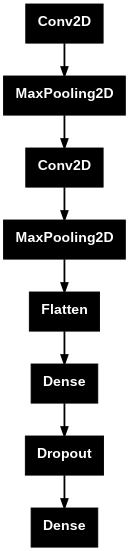

In [59]:
keras.utils.plot_model(model, dpi=64)

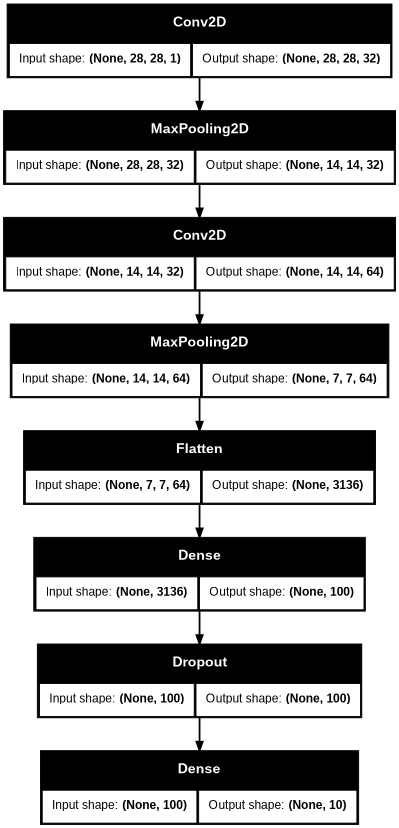

In [60]:
keras.utils.plot_model(model, dpi=64, show_shapes=True)

In [61]:
# 합성곱 신경망 컴파일
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [62]:
# 훈련 후 최적의 모델을 저장하기 위한 폴더/파일 경로
dir_path = '/content/drive/MyDrive/Colab Notebooks/lab_ml/'
file_path = dir_path + 'cnn_best_model.keras'

In [63]:
# 조기 종료, 저장 콜백
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [64]:
# 합성곱 신경망 훈련
result = model.fit(x=x_train_sc, y=y_train, batch_size=64, epochs=1_000,
                   validation_data=[x_test_sc, y_test],
                   callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - loss: 0.4865 - sparse_categorical_accuracy: 0.8256 - val_loss: 0.3419 - val_sparse_categorical_accuracy: 0.8756
Epoch 2/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - loss: 0.3170 - sparse_categorical_accuracy: 0.8854 - val_loss: 0.2867 - val_sparse_categorical_accuracy: 0.8966
Epoch 3/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - loss: 0.2734 - sparse_categorical_accuracy: 0.9011 - val_loss: 0.2657 - val_sparse_categorical_accuracy: 0.9032
Epoch 4/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - loss: 0.2426 - sparse_categorical_accuracy: 0.9118 - val_loss: 0.2550 - val_sparse_categorical_accuracy: 0.9099
Epoch 5/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - loss: 0.2191 - sparse_categorical_accuracy: 0.9192 - val_loss: 0.2377 - val_sparse_categorical_accuracy: 0.9152
Epoch 6/1000
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - loss: 0.1991 - sparse_categorical_accuracy: 0.9259 - val_loss: 0.2466 - val_sparse_categoric

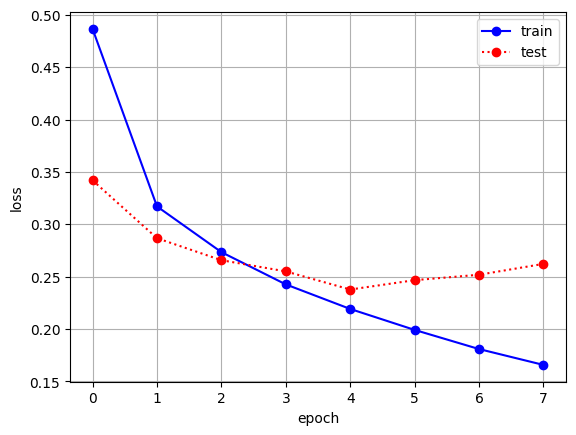

In [65]:
# 손실 그래프
epochs = result.epoch  # epoch 인덱스 list
history = result.history  # 훈련/검증 셋의 손실/정확도를 저장하고 있는 dict
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='test')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [66]:
# 훈련 셋 평가(손실, 정확도)
model.evaluate(x=x_train_sc, y=y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.1696 - sparse_categorical_accuracy: 0.9370


[0.1695505827665329, 0.9369999766349792]

In [67]:
# 테스트 셋 평가
model.evaluate(x=x_test_sc, y=y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.2377 - sparse_categorical_accuracy: 0.9152


[0.23770178854465485, 0.9151999950408936]

테스트 셋 혼동 행렬

Fashoin MNIST 데이터셋 클래스들:

티셔츠(0), 바지(1), 스웨터(2), 드레스(3), 코트(4), 샌달(5), 셔츠(6), 스니커즈(7), 가방(8), 앵클 부츠(9)

In [68]:
pred = model.predict(x=x_test_sc)  # 샘플들 마다 각 클래스가 될 예측 확률 10개를 리턴.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [69]:
pred.shape

(10000, 10)

In [70]:
pred[:2]

array([[1.2158711e-06, 6.6219549e-08, 1.6239977e-07, 2.0450680e-07,
        8.5350033e-10, 4.1527779e-05, 7.3397835e-08, 2.6876392e-04,
        2.3686783e-07, 9.9968779e-01],
       [8.9479063e-06, 1.3213253e-13, 9.9998397e-01, 3.6044420e-07,
        3.9934935e-06, 2.5839458e-14, 2.6802049e-06, 2.7976537e-15,
        2.9954541e-09, 8.3840656e-14]], dtype=float32)

In [71]:
pred_labels = np.argmax(pred, axis=1)  # 레이블 예측값

In [72]:
pred_labels.shape

(10000,)

In [73]:
pred_labels[:10]

array([9, 2, 1, 1, 6, 1, 2, 6, 5, 7])

In [74]:
y_test[:10]  # 실젯값

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

In [75]:
conf_mat = confusion_matrix(y_true=y_test, y_pred=pred_labels)
conf_mat

array([[884,   0,  23,  11,   6,   1,  67,   0,   7,   1],
       [  1, 985,   0,  14,   0,   0,   0,   0,   0,   0],
       [ 14,   1, 906,   7,  38,   0,  34,   0,   0,   0],
       [ 16,   3,  11, 927,  19,   0,  24,   0,   0,   0],
       [  1,   0,  84,  26, 851,   0,  38,   0,   0,   0],
       [  0,   0,   0,   0,   0, 981,   0,  16,   0,   3],
       [105,   1,  83,  25,  82,   0, 699,   0,   5,   0],
       [  0,   0,   0,   0,   0,   5,   0, 976,   0,  19],
       [  2,   2,   5,   4,   3,   1,   0,   4, 979,   0],
       [  0,   0,   1,   0,   0,   3,   0,  32,   0, 964]])

In [76]:
# 예측이 틀린 부분을 진하게 보기 위해서 대각선 값들을 0으로 바꿈
np.fill_diagonal(conf_mat, 0)
conf_mat

array([[  0,   0,  23,  11,   6,   1,  67,   0,   7,   1],
       [  1,   0,   0,  14,   0,   0,   0,   0,   0,   0],
       [ 14,   1,   0,   7,  38,   0,  34,   0,   0,   0],
       [ 16,   3,  11,   0,  19,   0,  24,   0,   0,   0],
       [  1,   0,  84,  26,   0,   0,  38,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  16,   0,   3],
       [105,   1,  83,  25,  82,   0,   0,   0,   5,   0],
       [  0,   0,   0,   0,   0,   5,   0,   0,   0,  19],
       [  2,   2,   5,   4,   3,   1,   0,   4,   0,   0],
       [  0,   0,   1,   0,   0,   3,   0,  32,   0,   0]])

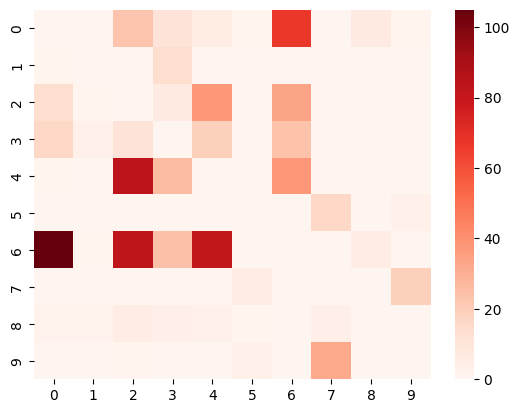

In [77]:
sns.heatmap(data=conf_mat, cmap='Reds')
plt.show()

# 훈련된 CNN에서 합성곱 층 시각화

## 첫번째 합성곱 층의 특성 맵 시각화

In [78]:
model  #> Sequential 클래스 객체

<Sequential name=sequential, built=True>

In [79]:
model.layers  #> CNN의 각 층(layer)들을 순서대로 저장한 배열(리스트)

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [80]:
model.layers[0]  #> CNN 모델의 첫번째 층 - Conv2D

<Conv2D name=conv2d, built=True>

In [81]:
model.layers[0].output  #> 첫번째 Conv2D 층의 출력은 (28, 28) 모양의 이미지 32장으로 해석.

<KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

In [82]:
model.inputs  #> CNN의 입력 층

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]

In [83]:
# 첫번째 합성곱 층의 출력만 보기 위해서, 입력층과 첫번째 합성곱 층만 연결한 모델을 생성
conv1_output_model = keras.Model(model.inputs, model.layers[0].output)

In [84]:
x_test_sc[0].shape

(28, 28, 1)

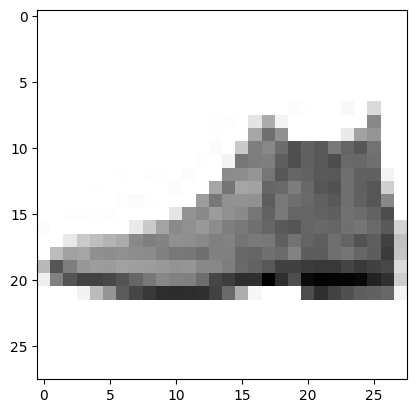

In [85]:
plt.imshow(x_test_sc[0].reshape((28, 28)), cmap=plt.cm.binary)
plt.show()

In [86]:
x_test_sc.shape  #> 4D

(10000, 28, 28, 1)

In [87]:
x_test_sc[0].shape  #> 3D

(28, 28, 1)

In [96]:
x_test_sc[:1].shape  #> 4D

(1, 28, 28, 1)

In [89]:
feature_map = conv1_output_model.predict(x_test_sc[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [90]:
feature_map.shape

(1, 28, 28, 32)

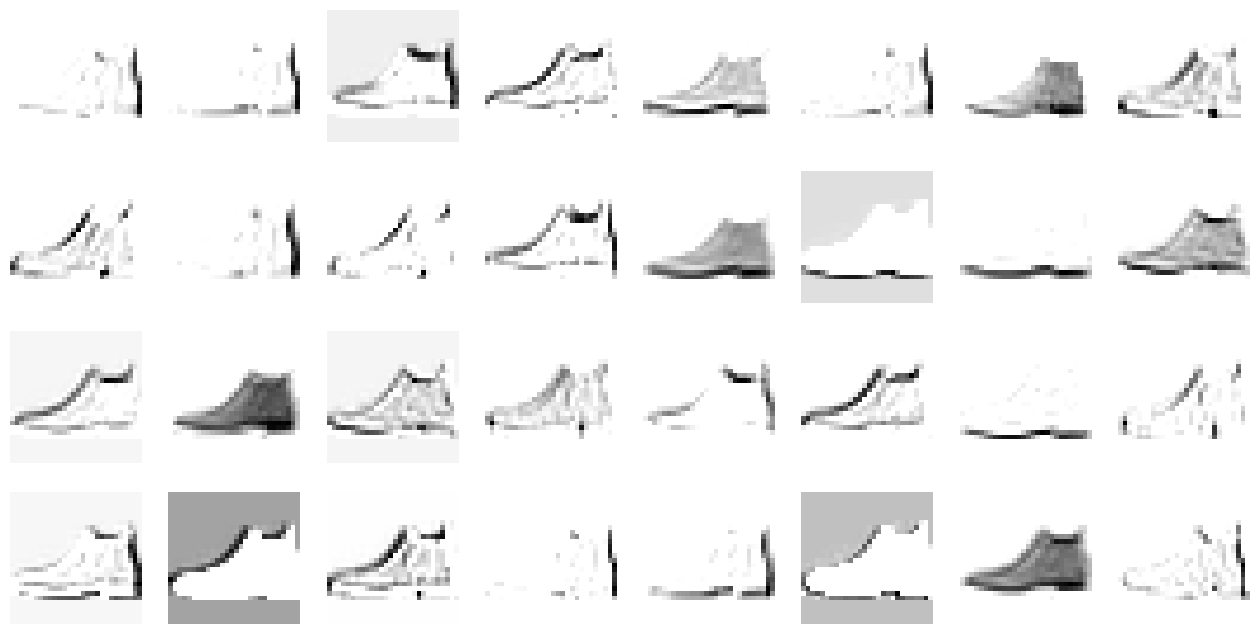

In [91]:
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
for i in range(4):
    for j in range(8):
        idx = i * 8 + j
        img = feature_map[0, :, :, idx]
        axes[i, j].imshow(img, cmap=plt.cm.binary)
        axes[i, j].axis('off')
plt.show()

## 두번째 합성곱 층의 특성 맵 시각화

In [92]:
conv2_output_model = keras.Model(model.inputs, model.layers[2].output)

In [93]:
feature_map_2 = conv2_output_model.predict(x_test_sc[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [94]:
feature_map_2.shape

(1, 14, 14, 64)

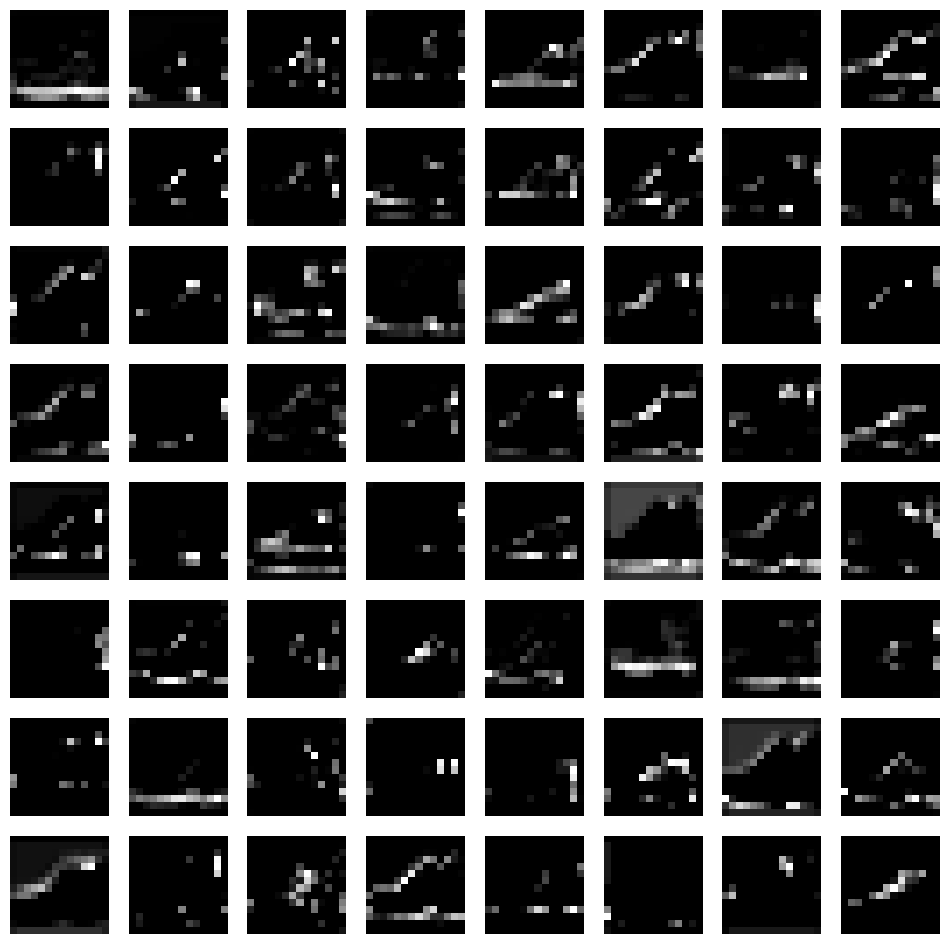

In [98]:
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        idx = i * 8 + j
        img = feature_map_2[0, :, :, idx]
        axes[i, j].imshow(img, cmap=plt.cm.gray)
        axes[i, j].axis('off')
plt.show()

# TF 합성곱 연산 시각화

In [99]:
sample_images = load_sample_images()

In [100]:
print(type(sample_images))  #> Bunch - dict와 비슷한 객체

<class 'sklearn.utils._bunch.Bunch'>


In [101]:
sample_images.keys()

dict_keys(['images', 'filenames', 'DESCR'])

In [102]:
images = sample_images['images']
print(type(images))  #> list

<class 'list'>


array([[[ 2, 19, 13],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 1, 77, 64],
        [ 0, 76, 64],
        [ 0, 75, 63]],

       [[ 1, 18, 12],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 0, 76, 64],
        [ 1, 74, 65],
        [ 1, 74, 65]],

       [[ 2, 17, 12],
        [ 6, 19, 12],
        [ 7, 20, 13],
        ...,
        [ 1, 74, 65],
        [ 1, 74, 67],
        [ 1, 74, 67]],

       ...,

       [[ 0, 46, 40],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 5, 44, 26],
        [ 6, 43, 26],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 6, 45, 27],
        [ 7, 44, 27],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 0, 46, 36],
        ...,
        [ 7, 46, 28],
        [ 8, 45, 28],
        [ 9, 43, 27]]], dtype=uint8)
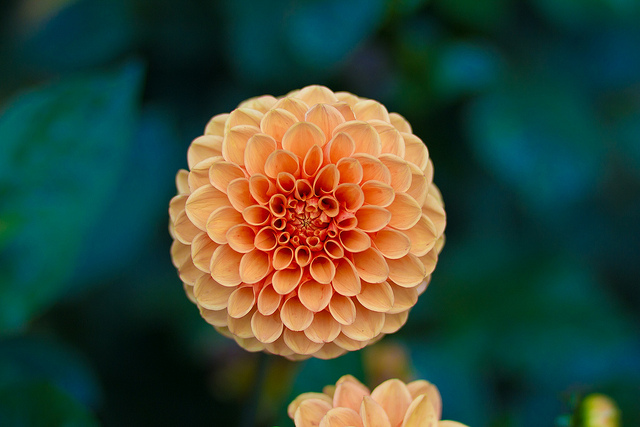

In [104]:
images[1]  #> (427, 640, 3) 모양의 ndarray 2개를 갖는 파이썬 list.

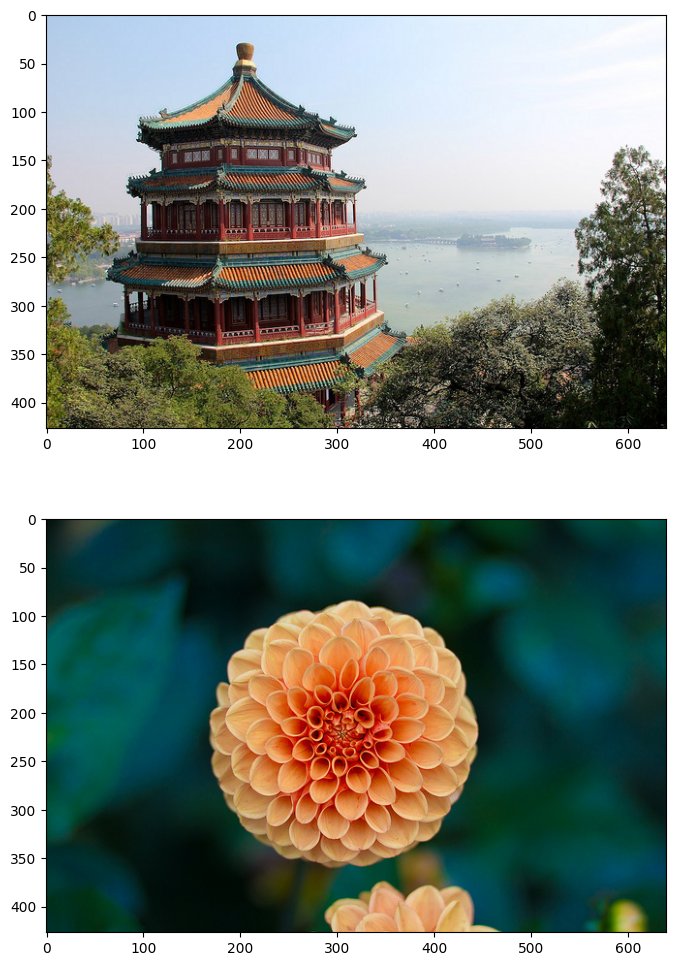

In [105]:
fig, axes = plt.subplots(nrows=2, figsize=(8, 12))
for i in range(2):
    axes[i].imshow(images[i])
plt.show()

In [106]:
# 이미지 자르기 - 이미지 정중앙에서 70x120 크기로 이미지를 자름.
crop_layer = keras.layers.CenterCrop(height=70, width=120)
images_crop = crop_layer(images)  #> images: (n_samples, height, width, channel)

In [107]:
images_crop.shape

TensorShape([2, 70, 120, 3])

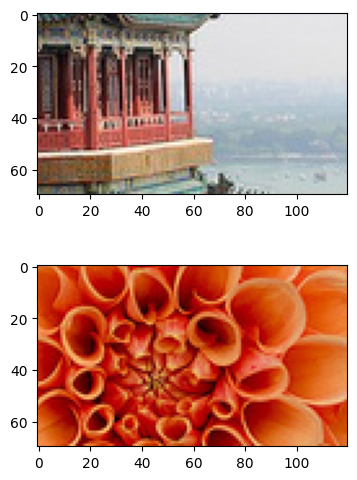

In [112]:
fig, axes = plt.subplots(nrows=2, figsize=(4, 6))
for i in range(2):
    img = tf.cast(images_crop[i], dtype=tf.uint8)
    axes[i].imshow(img)
plt.show()

In [113]:
# 이미지 픽셀 스케일링: 0 ~ 255 정수 스케일을 0.0 ~ 1.0 스케일로 변환
scale_layer = keras.layers.Rescaling(scale=1.0/255.0)
images_scaled = scale_layer(images_crop)

In [114]:
images_scaled.shape

TensorShape([2, 70, 120, 3])

In [115]:
# 2D 합성곱 연산을 수행하기 위한 필터들의 배열 - (7, 7, 3) 모양의 필터 2개
filters = np.zeros(shape=(7, 7, 3, 2))  # (filter_height, filter_width, filter_channel, n_filters)

# 첫번째 합성곱 필터는 가운데 수직선의 값들을 1로 변경, 나머지는 0 그대로 둚.
filters[:, 3, :, 0] = 1

# 두번째 합성곱 필터는 가운데 수평선의 값들을 1로 변경, 나머지는 0 그대로 둚.
filters[3, :, :, 1] = 1

In [116]:
# 2D convolution(합성곱) 연산을 수행
feature_maps = tf.nn.conv2d(input=images_scaled, filters=filters, strides=1, padding='SAME')

In [117]:
feature_maps.shape  #> (2, 70, 120, 2) = (n_sampels, height, width, n_filters)

TensorShape([2, 70, 120, 2])

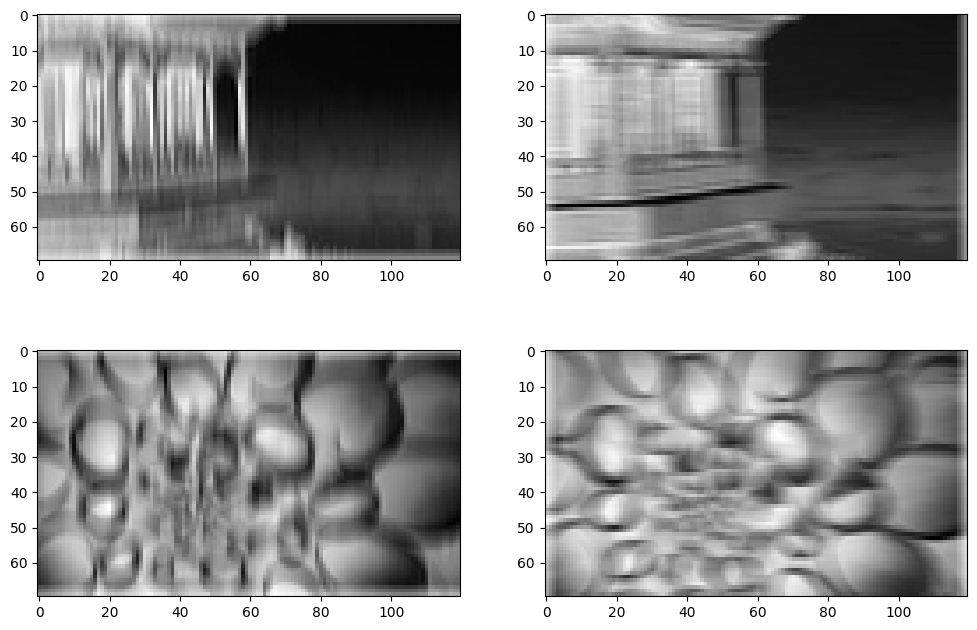

In [118]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
for i in range(2):
    for j in range(2):
        img = feature_maps[i, :, :, j]
        axes[i, j].imshow(img, cmap=plt.cm.binary)
plt.show()